Importing the necessary packages 


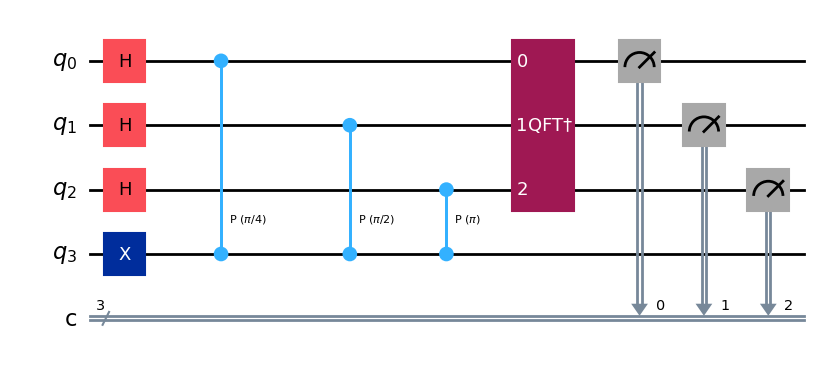

In [6]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit_aer.primitives import Sampler
import numpy as np
import matplotlib.pyplot as plt

# Number of counting qubits
n_count = 3

# Create the QPE circuit
qc = QuantumCircuit(n_count + 1, n_count)

# Initialize target qubit in |1⟩ (eigenvector of the T gate)
qc.x(n_count)

# Apply Hadamard to counting qubits
qc.h(range(n_count))

# Apply controlled-T^(2^j) gates
for j in range(n_count):
    angle = np.pi / 4 * (2 ** j)  # π/4 = phase for T gate
    qc.cp(angle, j, n_count)

# Apply inverse QFT
qft_dagger = QFT(num_qubits=n_count, inverse=True, do_swaps=True).to_gate()
qft_dagger.label = "QFT†"
qc.append(qft_dagger, range(n_count))

# Measure counting qubits
qc.measure(range(n_count), range(n_count))

# Display circuit
qc.draw('mpl')


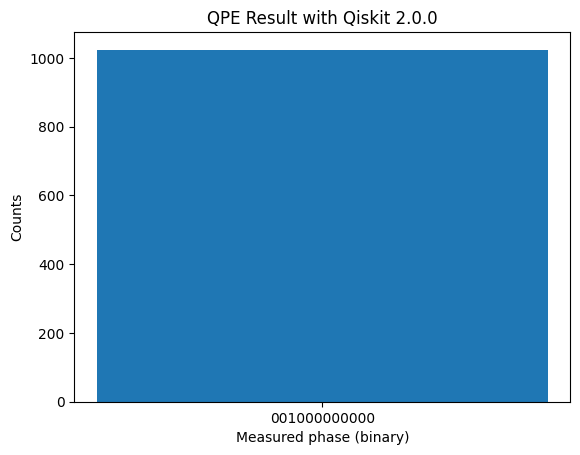

In [11]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit_aer.primitives import Sampler
import numpy as np
import matplotlib.pyplot as plt

# Number of counting qubits
n_count = 12

# Build QPE circuit
qc = QuantumCircuit(n_count + 1, n_count)

# Initialize target qubit to |1>
qc.x(n_count)

# Hadamard on counting qubits
qc.h(range(n_count))

# Controlled-T^(2^j) gates
for j in range(n_count):
    angle = np.pi / 4 * (2 ** j)
    qc.cp(angle, j, n_count)

# Inverse QFT
qft_dagger = QFT(n_count, inverse=True, do_swaps=True).to_gate()
qft_dagger.label = "QFT†"
qc.append(qft_dagger, range(n_count))

# Measurement
qc.measure(range(n_count), range(n_count))

# Create sampler (no backend argument in Qiskit 2.0.0)
sampler = Sampler()

# Run circuit
job = sampler.run([qc], shots=1024)
result = job.result()

# Extract quasi-distribution (probabilities)
quasi_dist = result.quasi_dists[0]

# Convert to counts for plotting
counts = {format(k, f'0{n_count}b'): int(v * 1024) for k, v in quasi_dist.items()}

# Plot the results
plt.bar(counts.keys(), counts.values())
plt.xlabel('Measured phase (binary)')
plt.ylabel('Counts')
plt.title('QPE Result with Qiskit 2.0.0')
plt.show()

In [2]:
from IPython.display import clear_output
from qiskit import QuantumCircuit  # import only what you need
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plotter
import seaborn as sns, operator
import time

sns.set_style("dark")

pi = np.pi


# Replacement for job_monitor for Qiskit 2.0.2+ runtime jobs
def runtime_job_monitor(job, poll_time=5):
    """Simple job monitor for IBM Runtime jobs."""
    while job.status().name not in ['DONE', 'CANCELLED', 'ERROR']:
        clear_output(wait=True)
        print(f"Job status: {job.status().name}")
        time.sleep(poll_time)
    clear_output(wait=True)
    print(f"Job finished with status: {job.status().name}")

In [3]:
## Code for inverse Quantum Fourier Transform
## adapted from Qiskit Textbook at
## qiskit.org/textbook

def qft_dagger(circ_, n_qubits):
    """n-qubit QFTdagger the first n qubits in circ"""
    for qubit in range(int(n_qubits/2)):
        circ_.swap(qubit, n_qubits-qubit-1)
    for j in range(0,n_qubits):
        for m in range(j):
            circ_.cp(-np.pi/float(2**(j-m)), m, j)
        circ_.h(j)

In [4]:
## Code for initial state of Quantum Phase Estimation
## adapted from Qiskit Textbook at qiskit.org/textbook
## Note that the starting state is created by applying 
## H on the first n_qubits, and setting the last qubit to |psi> = |1>

def qpe_pre(circ_, n_qubits):
    circ_.h(range(n_qubits))
    circ_.x(n_qubits)

    for x in reversed(range(n_qubits)):
        for _ in range(2**(n_qubits-1-x)):
            circ_.cp(1, n_qubits-1-x, n_qubits)

In [5]:
## Run a Qiskit job on either hardware or simulators

def run_job(circ, backend, shots=1000, optimization_level=0):
    t_circ = transpile(circ, backend, optimization_level=optimization_level)
    qobj = assemble(t_circ, shots=shots)
    job = backend.run(qobj)
    job_monitor(job)
    return job.result().get_counts()

In [7]:
from qiskit_ibm_provider import IBMProvider
from qiskit_aer import Aer
from qiskit_aer.primitives import Sampler as AerSampler

# Load your IBM Quantum account
provider = IBMProvider()  # Automatically loads stored IBM Cloud account

# Get backends
simulator_cloud = provider.get_backend('ibmq_qasm_simulator')
device = provider.get_backend('ibmq_16_melbourne')

# Local simulator with primitives interface
local_sampler = AerSampler()


ModuleNotFoundError: No module named 'qiskit_ibm_provider'

In [2]:
## Function to estimate pi
## Summary: using the notation in the Qiskit textbook (qiskit.org/textbook),
## do quantum phase estimation with the 'phase' operator U = p(theta) and |psi> = |1>
## such that p(theta)|1> = exp(2 x pi x i x theta)|1>
## By setting theta = 1 radian, we can solve for pi
## using 2^n x 1 radian = most frequently measured count = 2 x pi

def get_pi_estimate(n_qubits):

    # create the circuit
    circ = QuantumCircuit(n_qubits + 1, n_qubits)
    # create the input state
    qpe_pre(circ, n_qubits)
    # apply a barrier
    circ.barrier()
    # apply the inverse fourier transform
    qft_dagger(circ, n_qubits)
    # apply  a barrier
    circ.barrier()
    # measure all but the last qubits
    circ.measure(range(n_qubits), range(n_qubits))

    # run the job and get the results
    counts = run_job(circ, backend=simulator, shots=10000, optimization_level=0)
    # print(counts) 

    # get the count that occurred most frequently
    max_counts_result = max(counts, key=counts.get)
    max_counts_result = int(max_counts_result, 2)
    
    # solve for pi from the measured counts
    theta = max_counts_result/2**n_qubits
    return (1./(2*theta))

In [9]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np

def get_pi_estimate(n_count):
    # Your quantum circuit code here
    # ... (your existing circuit construction)
    
    # Updated simulator usage
    simulator = AerSimulator()
    transpiled = transpile(qc, simulator)
    job = simulator.run(transpiled, shots=1024)
    result = job.result()
    counts = result.get_counts()
    
    # Your pi estimation logic here
    # ... (return your pi estimate)

# Estimate pi using different numbers of qubits
nqs = list(range(2, 13))
pi_estimates = []

print("Quantum Pi Estimation Results:")
print("-" * 40)

for nq in nqs:
    try:
        thisnq_pi_estimate = get_pi_estimate(nq)
        pi_estimates.append(thisnq_pi_estimate)
        error = abs(thisnq_pi_estimate - np.pi)
        print(f"{nq:2d} qubits: π ≈ {thisnq_pi_estimate:.6f} (error: {error:.6f})")
    except Exception as e:
        print(f"{nq:2d} qubits: Error - {e}")

Quantum Pi Estimation Results:
----------------------------------------
 2 qubits: Error - name 'qc' is not defined
 3 qubits: Error - name 'qc' is not defined
 4 qubits: Error - name 'qc' is not defined
 5 qubits: Error - name 'qc' is not defined
 6 qubits: Error - name 'qc' is not defined
 7 qubits: Error - name 'qc' is not defined
 8 qubits: Error - name 'qc' is not defined
 9 qubits: Error - name 'qc' is not defined
10 qubits: Error - name 'qc' is not defined
11 qubits: Error - name 'qc' is not defined
12 qubits: Error - name 'qc' is not defined
